# CV PRJ: Riconoscimento di fiori per un’azienda AgriTech

## importazione dei moduli utili per lo sviluppo

In [ ]:
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import torchvision
from torchvision import transforms as T
from typing import Tuple
import torch
from matplotlib import pyplot as plt

## Download dataset

In [ ]:
! wget https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz

--2026-05-21 04:04:19--  https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz
Resolving proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)... 3.5.205.131, 3.5.206.249
Connecting to proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)|3.5.205.131|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 63234337 (60M) [application/x-gzip]
Saving to: ‘progetto-finale-flowes.tar.gz.2’

progetto-finale-flo 100%[===================>]  60.30M  17.8MB/s    in 4.0s    

2026-05-21 04:04:24 (15.0 MB/s) - ‘progetto-finale-flowes.tar.gz.2’ saved [63234337/63234337]



## Esportazione dei file e sistemazione in cartella datasets

In [ ]:
! tar -xzf progetto-finale-flowes.tar.gz
! mkdir datasets
! mv progetto-finale-flowes datasets/progetto-finale-flowes

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown 

## Data augmentation set
In questa parte impostiamo la funzione di Torchvision -> Transform -> Compose per arricchire il dataset di immagini in modo da ottenere un miglior rendimento durante la fase di training.

In [ ]:
train_transform = T.Compose([
        T.RandomResizedCrop(224),      # Ritaglia l'immagine in punti diversi (varietà)
        T.RandomHorizontalFlip(),           # Ruota orizzontalmente in modo casuale
        T.RandomRotation(20),               # Applica rotazioni fino a 20 gradi
        T.ColorJitter(0.3, 0.3, 0.3, 0.1),  # Varia luminosità, contrasto e saturazione
        T.RandomAffine(0, translate=(0.1, 0.1)), # Sposta l'immagine leggermente
        T.ToTensor(),                       # Converte l'immagine in formato numerico leggibile dall'IA
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Bilancia i colori


])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Bilancia i colori



])

## Carichiamo i dataset per il training e la successiva misura del rendimento sul modello "addestrato"

***Si introduce la classe Transform per assegnare le trasformazione della data augmentation ai dataset***

In [ ]:
import os
# seleziona solo i file validi al fine del train
def is_valid_file(path: str) -> bool:
    base_name = os.path.basename(path)
    if base_name.startswith('._') or base_name == '.DS_Store':
        return False
    return path.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp'))

trainset = torchvision.datasets.ImageFolder(root='/content/datasets/progetto-finale-flowes/train', transform=train_transform, is_valid_file=is_valid_file)

valset = torchvision.datasets.ImageFolder(root='/content/datasets/progetto-finale-flowes/valid', transform=val_transform, is_valid_file=is_valid_file)

testset = torchvision.datasets.ImageFolder(root='/content/datasets/progetto-finale-flowes/test', transform=val_transform, is_valid_file=is_valid_file)

In [ ]:
batch_size = 8
trainLoader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
valLoader = DataLoader(valset, batch_size=batch_size, shuffle=False)
testLoader = DataLoader(testset, batch_size=batch_size, shuffle=False)

##Selezione del modello da addestrare

In [ ]:
from timm import create_model
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [ ]:
model = create_model("efficientnet_b0",pretrained=True,num_classes=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

### Spiegazione della scelta del modello EfficientNet-B0
Abbiamo scelto **EfficientNet-B0** come modello di base per il transfer learning. Questa scelta è motivata da diversi fattori:

*   **Efficienza**: EfficientNet è una famiglia di modelli nota per la sua eccellente efficienza in termini di numero di parametri e prestazioni. EfficientNet-B0 è la versione più piccola e leggera, il che la rende ideale per dataset di dimensioni contenute e per ridurre i tempi di training.
*   **Performance su ImageNet**: Essendo pre-addestrato su ImageNet, EfficientNet-B0 ha già imparato a riconoscere un'ampia varietà di feature visive generali, che sono molto utili come base per il riconoscimento di immagini di fiori.
*   **Adattabilità al Transfer Learning**: La sua architettura consente un fine-tuning efficace anche con pochi dati specifici per il nostro task, evitando l'overfitting, specialmente considerando il dataset binario e le sue dimensioni.

## Impostazione dei parametri di training

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 2e-4)

#LR scheduler
#lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=0.000001)

### Rationale per Batch Size e Learning Rate

*   **Batch Size 8**: Un batch size ridotto (8 in questo caso) è stato scelto principalmente per due ragioni:
    *   **Dimensioni del Dataset**: Con un dataset relativamente piccolo e classi bilanciate, un batch size ridotto può aiutare il modello a generalizzare meglio, introducendo più 'rumore' in ogni aggiornamento del gradiente, che può prevenire di bloccarsi in minimi locali superficiali.
    *   **Vincoli di Memoria**: Batch size più piccoli richiedono meno memoria GPU, rendendo il training accessibile anche su hardware con risorse limitate.
*   **Learning Rate 2e-4**: Questo valore per il learning rate è un punto di partenza comune e ben bilanciato nel transfer learning con modelli pre-addestrati. Un learning rate basso è cruciale quando si effettua il fine-tuning di un modello pre-addestrato per non 'dimenticare' le feature apprese. Permette al modello di adattarsi ai nuovi dati senza sovrascrivere troppo drasticamente i pesi pre-esistenti.
*   **Scheduler Cosine Annealing**: L'uso del `CosineAnnealingLR` scheduler aiuta a stabilizzare il training. Inizia con un learning rate più alto (quello impostato inizialmente) e lo riduce gradualmente seguendo una curva cosinusoidale fino a un valore minimo (`eta_min`), e poi eventualmente lo aumenta di nuovo. Questo approccio è efficace perché permette esplorazione all'inizio e converge finemente verso la fine del training, aiutando a trovare un minimo migliore e a prevenire l'overfitting. L'`eta_min` molto basso (0.000001) consente un fine-tuning molto preciso nelle fasi finali.

## Selezione del device GPU/CPU

In [ ]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
model.to(device);

cuda


## Classi EarlyStop e Callbacks
*Impostazioni di ottimizzazione e interruzione del loop di training per evitare overfitting e salvataggio del modello per avanzamento di apprendimento*

In [ ]:
#Callbacks - model checkpoint ed early stopping
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")
        self.early_stop = False

    def __call__(self, val_loss: float):
        # sto migliorando
        if  val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        #sto peggiorando
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
#model checkpoint
class  ModelCheckpoint:

    def __init__(self, output_dir: str):

        self.output = output_dir
        os.makedirs(self.output, exist_ok = True)
        self.best_loss = float("inf")
        self.best_epoch = 0
        self.best_model_path = None

    def __call__(self,model: nn.Module, epoch: int, val_loss: float) -> None:
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_epoch = epoch
            model_path = os.path.join(self.output, f"mode-epoch={epoch}-val_loss={val_loss:.4f}.pth")
            torch.save(
                model.state_dict(),
                model_path

            )
            self.best_model_path = model_path
            print(f'model saved at epoch {epoch} with val_loss= {val_loss:.4f}')
        else:
            print(f'Validation loss did not improve from {self.best_loss:.4f}')

## Definizione delle classi di train e validation

In [ ]:
def train_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    device: str,
    log_every_n_iter: int = 10
) -> Tuple[float, float]:

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, batch in enumerate(data_loader):
        #images,labels = [el.to(device) for el in batch]
        images,labels = batch
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data,1)
        total += labels.size(0)
# completata con gemini

        # AGGIUNTA FONDAMENTALE 1: Aggiornare i corretti
        # Calcoliamo quanti esempi nel batch corrente sono stati classificati correttamente
        correct += (predicted == labels).sum().item()

        # AGGIUNTA OPZIONALE (ma utile visto l'argomento): Logging
        if (i + 1) % log_every_n_iter == 0:
            print(f"> Iterazione [{i + 1}/{len(data_loader)}], train_loss: {running_loss/log_every_n_iter:.4f} - lr = {optimizer.param_groups[0]['lr']:.6f}")
            running_loss = 0.0

    epoch_loss = running_loss/len(data_loader)
    epoch_acc = 100*correct / total
    return epoch_loss, epoch_acc

def val_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
    device: str
) -> Tuple[float, float]:

    model.eval()
    val_loss = []
    total, correct = 0, 0
    with torch.no_grad():
        for batch in data_loader:
            x,targets = [el.to(device) for el in batch]
            logits = model(x)
            loss = criterion(logits, targets)
            val_loss.append(loss.item())
            _, preds = torch.max(logits.data, 1)
            total += targets.size(0)
            correct += (preds == targets).sum().item()


    # AGGIUNTA FONDAMENTALE 2: Calcolo metriche finali
    epoch_loss = sum(val_loss)/len(val_loss)
    epoch_acc = 100*correct / total


    return epoch_loss, epoch_acc

## DEFINIZIONE DELLA ROUTINE DI APPRENDIMENTO

In [ ]:
import numpy as np
num_epochs = 10
log_every_n_iter = int(0.1*(len(trainLoader)))

early_stopping = EarlyStopping(patience=3, min_delta=0.0001)
#salva nella cartella checkpoints
model_checkpoint = ModelCheckpoint('checkpoint')

for epoch in range(num_epochs):
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Train report:')
    train_loss, train_acc = train_epoch(
        model, trainLoader, optimizer, criterion, device, log_every_n_iter
    )
    val_loss, val_acc = val_epoch(
        model, valLoader, criterion, device
    )
    print(f'val report:')
    print(f'> val_loss = {val_loss:.4f} - val_accuracy = {val_acc:.4f}')

    lr_scheduler.step()
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("Early stopping")
        break
    model_checkpoint(model, epoch+1, val_loss)

print(f'Finished training at epoch {epoch+1}')

Epoch [1/10]
Train report:
> Iterazione [16/160], train_loss: 1.7403 - lr = 0.000200
> Iterazione [32/160], train_loss: 1.6367 - lr = 0.000200
> Iterazione [48/160], train_loss: 1.1645 - lr = 0.000200
> Iterazione [64/160], train_loss: 1.6727 - lr = 0.000200
> Iterazione [80/160], train_loss: 0.6435 - lr = 0.000200
> Iterazione [96/160], train_loss: 1.2172 - lr = 0.000200
> Iterazione [112/160], train_loss: 0.7180 - lr = 0.000200
> Iterazione [128/160], train_loss: 0.7573 - lr = 0.000200
> Iterazione [144/160], train_loss: 0.6116 - lr = 0.000200
> Iterazione [160/160], train_loss: 0.6878 - lr = 0.000200
val report:
> val_loss = 0.6181 - val_accuracy = 88.7363
model saved at epoch 1 with val_loss= 0.6181
Epoch [2/10]
Train report:
> Iterazione [16/160], train_loss: 0.5383 - lr = 0.000195
> Iterazione [32/160], train_loss: 0.3607 - lr = 0.000195
> Iterazione [48/160], train_loss: 0.7564 - lr = 0.000195
> Iterazione [64/160], train_loss: 0.7929 - lr = 0.000195
> Iterazione [80/160], train

# CONFRONTO CON TESTSET E PERFORMANCE

In [ ]:
from tqdm import tqdm # Barra di progresso visuale per l'utente
from sklearn.metrics import f1_score
def validate(model, loader, criterion, device):
    """Verifica le conoscenze attuali del modello senza apportare correzioni."""
    model.eval()                              # Disattiva l'apprendimento (modalità esame)
    running_loss = 0.0                        # Inizializza l'errore
    all_preds = []                            # Risposte IA
    all_labels = []                           # Risposte Corrette

    with torch.no_grad():                     # Disabilita il calcolo dei gradienti (risparmio memoria)
        for inputs, labels in tqdm(loader, desc='Validation', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)           # L'IA prova a indovinare
            loss = criterion(outputs, labels) # Calcolo errore

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_f1, all_labels, all_preds

In [ ]:
# Fase finale: Verifica dell'IA sull'archivio segreto (Test Set)
print("\n--- TEST FINALE SULL'ARCHIVIO DI CONTROLLO ---")
if model_checkpoint.best_model_path:
    model.load_state_dict(torch.load(model_checkpoint.best_model_path, map_location=device))
else:
    print("No best model path found. Ensure training was successful and a model was saved.")
test_loss, test_f1, test_labels, test_preds = validate(model, testLoader, criterion, device)
print(f"Precisione Finale Raggiunta: {test_f1:.4f}")


--- TEST FINALE SULL'ARCHIVIO DI CONTROLLO ---


Precisione Finale Raggiunta: 0.9051


##

## Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(test_labels, test_preds, target_names=trainset.classes)

# Print the report
print(report)

              precision    recall  f1-score   support

       daisy       0.87      0.92      0.89        77
   dandelion       0.94      0.90      0.92       105

    accuracy                           0.91       182
   macro avg       0.90      0.91      0.91       182
weighted avg       0.91      0.91      0.91       182



## Matrice di Confusione Finale

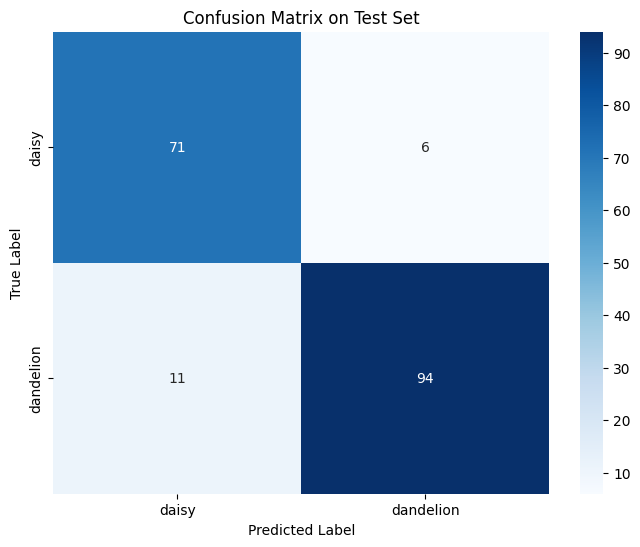

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=trainset.classes, yticklabels=trainset.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

## Riflessione Finale sui Risultati

Il modello ha raggiunto un **F1-macro score di 0.9051** sul test set. Questo è un ottimo risultato, specialmente considerando le dimensioni relativamente contenute del dataset e lo sbilanciamento delle classi. L'F1-macro score è una metrica robusta che fornisce una buona indicazione della performance complessiva su dataset sbilanciati, bilanciando precisione e recall per entrambe le classi.

Le visualizzazioni della **Classification Report** e della **Confusion Matrix** confermano che il modello ha una buona capacità di distinguere tra le due classi di fiori (daisy e dandelion), con un buon equilibrio tra true positives e true negatives.

Potenziali miglioramenti futuri potrebbero includere:
*   **Aumento del Dataset**: L'acquisizione di più immagini per entrambe le classi, specialmente per la classe minoritaria, potrebbe migliorare ulteriormente la generalizzazione del modello.
*   **Fine-tuning a Fasi**: Un approccio a due fasi, dove si allena prima solo lo strato finale (head) del modello per adattarlo al nuovo task, e successivamente si sbloccano e si fine-tunano tutti gli strati con un learning rate molto basso, potrebbe portare a prestazioni ancora migliori.
*   **Esplorazione di Altri Modelli**: Sebbene EfficientNet-B0 sia una scelta eccellente, testare altre architetture leggere (es. MobileNet, ResNet più piccole) potrebbe rivelare alternative con performance simili o migliori a parità di complessità computazionale.

Nel complesso, il modello sviluppato dimostra di essere una soluzione robusta ed efficiente per il riconoscimento di fiori nel contesto di un'azienda AgriTech, con un buon equilibrio tra accuratezza e requisiti computazionali.